# Cosmo-Edu Lab: Galaxy Clusters and Dark Matter 🌌

By observing the radial velocities of galaxies moving within a cluster (using actual telescope data!), we can figure out how much total mass is pulling them together using gravity. Then, we will sum up all the visible mass (stars and gas). The missing mass? That's **Dark Matter**.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.integrate import quad

# --- FUNDAMENTAL CONSTANTS ---
G_grav = 4.30091e-6  # Gravitational constant in (kpc * (km/s)^2) / M_sun
c_light = 3e5        # Speed of light in km/s
H0 = 70.0            # Hubble constant in (km/s) / Mpc

print("Libraries imported and constants defined! Ready for physics.")

Libraries imported and constants defined! Ready for physics.


## Step 1: Cosmology and the Critical Density

To measure distances in the Universe, we must account for its expansion. We use the **Hubble Constant** ($H_0$) and the **redshift** ($z$) of the galaxies to calculate their distance from us.

We also need to define the **Critical Density** ($\rho_{crit}$) of the Universe. This is the exact density required for the Universe to be flat.

$$ \rho_{crit} = \frac{3 H_0^2}{8 \pi G} $$

We define our cluster's boundary at $R_{200}$, which is the radius within which the average density of the cluster is 200 times the critical density of the Universe.

In [2]:
# Cosmological distance functions
def comoving_distance_Mpc(z, Om=0.3):
    integrand = lambda zp: 1.0 / np.sqrt(Om*(1.0+zp)**3 + (1.0-Om))
    chi, _ = quad(integrand, 0.0, z)
    return (c_light / H0) * chi

def angular_diameter_distance_Mpc(z, Om=0.3):
    return comoving_distance_Mpc(z, Om) / (1.0 + z)

def rho_crit_Msunkpc3():
    H0_kpc = H0 / 1000.0
    return 3.0 * (H0_kpc**2) / (8.0 * np.pi * G_grav)

def angsep_rad(ra1_deg, dec1_deg, ra2_deg, dec2_deg):
    ra1 = np.deg2rad(ra1_deg); dec1 = np.deg2rad(dec1_deg)
    ra2 = np.deg2rad(ra2_deg); dec2 = np.deg2rad(dec2_deg)
    cos_theta = np.clip(np.sin(dec1)*np.sin(dec2) + np.cos(dec1)*np.cos(dec2)*np.cos(ra1 - ra2), -1.0, 1.0)
    return np.arccos(cos_theta)

rho_crit_local = rho_crit_Msunkpc3()
print(f"Local Critical Density: {rho_crit_local:.2e} Solar Masses per cubic kpc")

Local Critical Density: 1.36e+02 Solar Masses per cubic kpc


## Step 2: Loading real telescope data and filtering outliers

Upload your cluster dataset (e.g., `Abell1656(Coma).csv` or `Abell_XYZ.txt`) to Google Colab using the file menu on the left.

When we observe a cluster, we also see background and foreground galaxies. We need to find the "velocity peak" of the cluster and apply a statistical method called **3-Sigma Clipping** to remove the intruders. Then, we convert the brightness of the remaining galaxies into physical **Stellar Mass**.

In [4]:
import glob
import os
import numpy as np
import pandas as pd

# --- HELPER FUNCTION ---
# We define a function to calculate the Virial Mass (M200) and Radius (R200)
def estimate_M200_R200_from_sigma(sigma_obs, rho_crit_local):
    if sigma_obs <= 0: return 1e14, 1000.0
    R200 = np.sqrt((9.0 * sigma_obs**2) / (4.0 * np.pi * G_grav * 200.0 * rho_crit_local))
    M200 = (4.0/3.0) * np.pi * 200.0 * rho_crit_local * R200**3
    return M200, R200

# --- READ THE DATASETS ---
# Ensure your files are uploaded to Colab or Google Drive with these paths
coma_files = glob.glob("/content/drive/MyDrive/Cosmo-Edu-Lab/Abell1656(Coma).csv")
abell_files = glob.glob("/content/drive/MyDrive/Cosmo-Edu-Lab/cluster_data_tot/Abell*.txt")
all_files = list(set(coma_files + abell_files))

clusters_data = {}

for file in sorted(all_files):
    cluster_name = os.path.basename(file).replace('.txt', '').replace('.csv', '')

    try:
        if "coma" in cluster_name.lower():
            # --- 1. COMA CLUSTER PIPELINE ---
            df = pd.read_csv(file, skiprows=1)
            df.columns = ['objid','ra','dec','modelmag_r','modelmagerr_r','extinction_r','redshift','zErr']
            df = df.dropna(subset=['ra', 'dec', 'redshift', 'modelmag_r'])
            df['RV'] = c_light * df['redshift']

            # Find velocity peak to isolate the cluster
            counts, bin_edges = np.histogram(df["RV"], bins=50)
            v_peak = (bin_edges[np.argmax(counts)] + bin_edges[np.argmax(counts) + 1]) / 2.0
            df = df[(df["RV"] >= v_peak - 6000) & (df["RV"] <= v_peak + 6000)]
            members = df.copy()

            # 3-Sigma Clipping to remove outliers
            for _ in range(5):
                v_rel = members["RV"] - np.median(members["RV"])
                mad = np.median(np.abs(v_rel))
                sigma_clip = 1.4826 * mad if mad > 0 else np.std(v_rel)
                mask = np.abs(v_rel) <= 3 * sigma_clip
                new_members = members[mask]
                if len(new_members) == len(members): break
                members = new_members

            # Safety filter: We need at least 5 galaxies to do physics!
            if len(members) < 5:
                print(f"{cluster_name:<15} | DISCARDED: Only {len(members)} members post-filter")
                continue

            # Extract numpy arrays for math
            observed_vel = members['RV'].values
            z_cluster = np.nanmedian(members['redshift'].values)
            center_ra, center_dec = np.nanmedian(members['ra'].values), np.nanmedian(members['dec'].values)

            D_A_kpc = angular_diameter_distance_Mpc(z_cluster) * 1000.0
            theta_rad = angsep_rad(members['ra'].values, members['dec'].values, center_ra, center_dec)
            r = np.maximum(theta_rad * D_A_kpc, 1e-3)

            mag = members['modelmag_r'].values - members['extinction_r'].values
            D_L_Mpc = (c_light * z_cluster) / H0
            dist_mod = 5 * np.log10(D_L_Mpc * 1e6) - 5
            M_abs = mag - dist_mod
            L_B = 10.0**(0.4 * (4.67 - M_abs))
            MLR = 2.0

        else:
            # --- 2. ABELL CLUSTERS PIPELINE ---
            df = pd.read_csv(file, sep=r"\s+", header=None)
            if df.shape[1] == 7: df[7] = np.nan
            df = df.iloc[:, :8]
            df.columns = ["Cluster", "ID", "RAdeg", "DEdeg", "RV", "e_RV", "q_RV", "bmag"]
            for col in ["RAdeg", "DEdeg", "RV", "bmag"]: df[col] = pd.to_numeric(df[col], errors="coerce")
            df = df.dropna(subset=["RAdeg", "DEdeg", "RV", "bmag"])
            df = df[df["bmag"] > 0.0]

            # Find velocity peak to isolate the cluster
            counts, bin_edges = np.histogram(df["RV"], bins=50)
            v_peak = (bin_edges[np.argmax(counts)] + bin_edges[np.argmax(counts) + 1]) / 2.0
            df = df[(df["RV"] >= v_peak - 6000) & (df["RV"] <= v_peak + 6000)]
            members = df.copy()

            # 3-Sigma Clipping to remove outliers
            for _ in range(5):
                v_rel = members["RV"] - np.median(members["RV"])
                mad = np.median(np.abs(v_rel))
                sigma_clip = 1.4826 * mad if mad > 0 else np.std(v_rel)
                mask = np.abs(v_rel) <= 3 * sigma_clip
                new_members = members[mask]
                if len(new_members) == len(members): break
                members = new_members

            # Safety filter: We need at least 5 galaxies to do physics!
            if len(members) < 5:
                print(f"{cluster_name:<15} | DISCARDED: Only {len(members)} members post-filter")
                continue

            cluster_distance = np.median(members["RV"]) / H0
            mean_ra, mean_dec = members["RAdeg"].mean(), members["DEdeg"].mean()
            ang_sep = np.sqrt(((members["RAdeg"] - mean_ra) * np.cos(np.radians(mean_dec)))**2 + (members["DEdeg"] - mean_dec)**2)
            r = cluster_distance * 1000 * np.radians(ang_sep)

            # FIX: Assign to DataFrame and extract pure numpy arrays (.values) to avoid IndexErrors!
            members = members.assign(r_kpc=r).dropna(subset=["r_kpc"])

            r = members["r_kpc"].values
            observed_vel = members["RV"].values
            bmag = members["bmag"].values

            D_pc = cluster_distance * 1e6
            dist_mod = 5*np.log10(D_pc) - 5
            M_abs = bmag - dist_mod
            L_B = 10**(-0.4*(M_abs - 5.48))
            MLR = 5.0

        # --- 3. SORTING AND CUMULATIVE MASS ---
        # Sort galaxies by their distance from the cluster center
        order = np.argsort(r)
        r_sorted = r[order]
        observed_vel_sorted = observed_vel[order]

        L_cum = np.cumsum(L_B[order])
        M_lum_r = MLR * L_cum
        M_star_tot = M_lum_r[-1]

        # Store validated data for the next steps
        clusters_data[cluster_name] = {
            "r_sorted": r_sorted,
            "observed_vel_sorted": observed_vel_sorted,
            "M_lum_r": M_lum_r,
            "M_star_tot": M_star_tot
        }
        print(f"✅ Data successfully loaded and filtered for {cluster_name}")

    except Exception as e:
        print(f"Error {cluster_name}: {str(e)}")

✅ Data successfully loaded and filtered for Abell1656(Coma)
✅ Data successfully loaded and filtered for Abell0080
✅ Data successfully loaded and filtered for Abell0118
✅ Data successfully loaded and filtered for Abell0380
✅ Data successfully loaded and filtered for Abell2734
✅ Data successfully loaded and filtered for Abell2778
✅ Data successfully loaded and filtered for Abell2799
✅ Data successfully loaded and filtered for Abell2800
✅ Data successfully loaded and filtered for Abell2819
✅ Data successfully loaded and filtered for Abell2854
✅ Data successfully loaded and filtered for Abell2871
✅ Data successfully loaded and filtered for Abell2911
✅ Data successfully loaded and filtered for Abell2915
✅ Data successfully loaded and filtered for Abell2923
✅ Data successfully loaded and filtered for Abell2933
✅ Data successfully loaded and filtered for Abell3107
✅ Data successfully loaded and filtered for Abell3111
Abell3112       | DISCARDED: Only 0 members post-filter
✅ Data successfully 

/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


✅ Data successfully loaded and filtered for Abell3189
✅ Data successfully loaded and filtered for Abell3194
✅ Data successfully loaded and filtered for Abell3223
✅ Data successfully loaded and filtered for Abell3264
✅ Data successfully loaded and filtered for Abell3764
✅ Data successfully loaded and filtered for Abell3809
✅ Data successfully loaded and filtered for Abell3844
✅ Data successfully loaded and filtered for Abell3864
✅ Data successfully loaded and filtered for Abell3915
✅ Data successfully loaded and filtered for Abell3921
✅ Data successfully loaded and filtered for Abell4010
✅ Data successfully loaded and filtered for Abell4067
✅ Data successfully loaded and filtered for Abell487


## Step 3: The Virial Theorem and Mass Budget

Since the cluster is stable, the kinetic energy of the galaxies is balanced by the gravitational potential energy. This is the **Virial Theorem** ($2<K>+<U>=0$).

By calculating the velocity dispersion ($\sigma$) of our clean dataset, we can find the total dynamical mass. Then, we estimate the X-ray gas, and calculate the Dark Matter by subtraction!

In [5]:
results_data = []
valid_clusters_for_plot = {}

print(f"{'Cluster':<15} | {'M_tot (M_sun)':<12} | {'% DM':<8}")
print("-" * 45)

for cluster_name, data in clusters_data.items():
    try:
        r_sorted = data["r_sorted"]
        observed_vel_sorted = data["observed_vel_sorted"]
        M_star_tot = data["M_star_tot"]
        M_lum_r = data["M_lum_r"]

        # Calculate Velocity Dispersion (sigma)
        if "coma" in cluster_name.lower():
            sigma_global = np.std(observed_vel_sorted)
        else:
            sigma_global = np.std(observed_vel_sorted - np.median(observed_vel_sorted))

        # Weighing the cluster using the Virial Theorem
        M200, R200 = estimate_M200_R200_from_sigma(sigma_global, rho_crit_local)
        M_tot = M200

        # --- PHYSICAL INTEGRITY FILTERS ---
        if M_tot > 5e15:
            print(f"{cluster_name:<15} | DISCARDED: Mass too large ({M_tot:.2e} M_sun > 5e15)")
            continue
        elif M_tot < 1e13:
            print(f"{cluster_name:<15} | DISCARDED: Mass too small ({M_tot:.2e} M_sun < 1e13)")
            continue

        # Calculate Gas Mass and Dark Matter
        f_gas_global = 0.093 * (((0.7 * M_tot) / 2e14)**0.21)
        M_gas_tot = (0.7 * M_tot) * f_gas_global
        M_DM_tot = np.maximum(0.0, M_tot - M_star_tot - M_gas_tot)

        perc_dm = (M_DM_tot / M_tot) * 100.0

        # Save data for the scatter plot
        results_data.append({
            "Cluster": cluster_name,
            "M_tot": M_tot,
            "Perc_DM": perc_dm
        })

        # Save valid data for the histograms
        valid_clusters_for_plot[cluster_name] = {
            "r_sorted": r_sorted,
            "observed_vel_sorted": observed_vel_sorted,
            "M_lum_r": M_lum_r,
            "sigma_global": sigma_global,
            "f_gas_global": f_gas_global
        }

        print(f"{cluster_name:<15} | {M_tot:<12.2e} | {perc_dm:<8.3f}%")

    except Exception as e:
        print(f"Error evaluating mass for {cluster_name}: {str(e)}")

Cluster         | M_tot (M_sun) | % DM    
---------------------------------------------
Abell1656(Coma) | 1.64e+15     | 90.036  %
Abell0080       | 4.90e+13     | 89.036  %
Abell0118       | 1.34e+15     | 90.802  %
Abell0380       | 2.93e+15     | 89.266  %
Abell2734       | 1.52e+15     | 90.372  %
Abell2778       | DISCARDED: Mass too large (1.74e+16 M_sun > 5e15)
Abell2799       | DISCARDED: Mass too small (2.76e+12 M_sun < 1e13)
Abell2800       | 7.60e+13     | 90.206  %
Abell2819       | 5.76e+13     | 91.647  %
Abell2854       | 6.11e+13     | 89.963  %
Abell2871       | DISCARDED: Mass too large (2.35e+16 M_sun > 5e15)
Abell2911       | 3.54e+14     | 92.257  %
Abell2915       | DISCARDED: Mass too large (5.41e+16 M_sun > 5e15)
Abell2923       | 4.55e+14     | 92.185  %
Abell2933       | 8.67e+14     | 91.237  %
Abell3107       | DISCARDED: Mass too large (2.01e+16 M_sun > 5e15)
Abell3111       | DISCARDED: Mass too large (9.38e+15 M_sun > 5e15)
Abell3122       | 1.29e+15    

## Step 4: Visualizing the Physics (Velocity Distribution)

Let's test our model! We will generate simulated velocities for our galaxies based purely on the gravity generated by:
1. **Baryonic Mass only** (Stars + Gas)
2. **Total Mass** (Virial Theorem)

Let's see which one matches the actual observations recorded by the telescope!

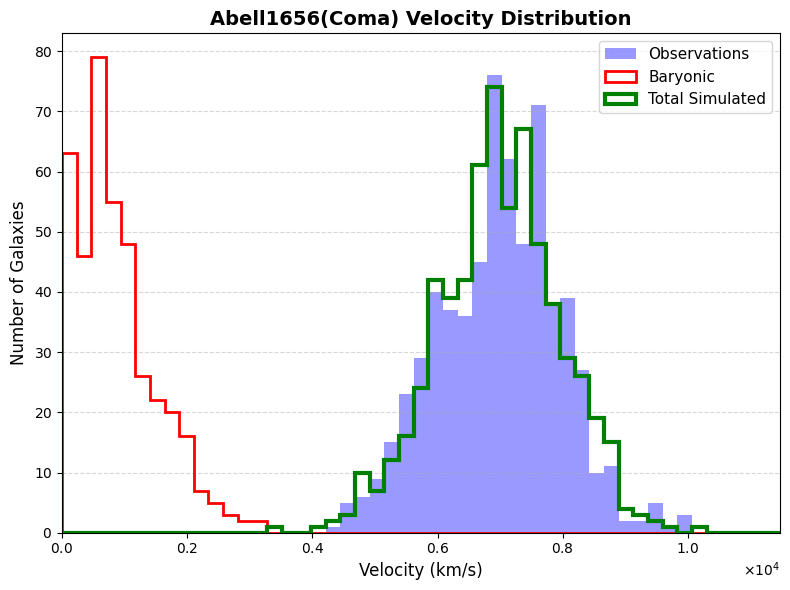

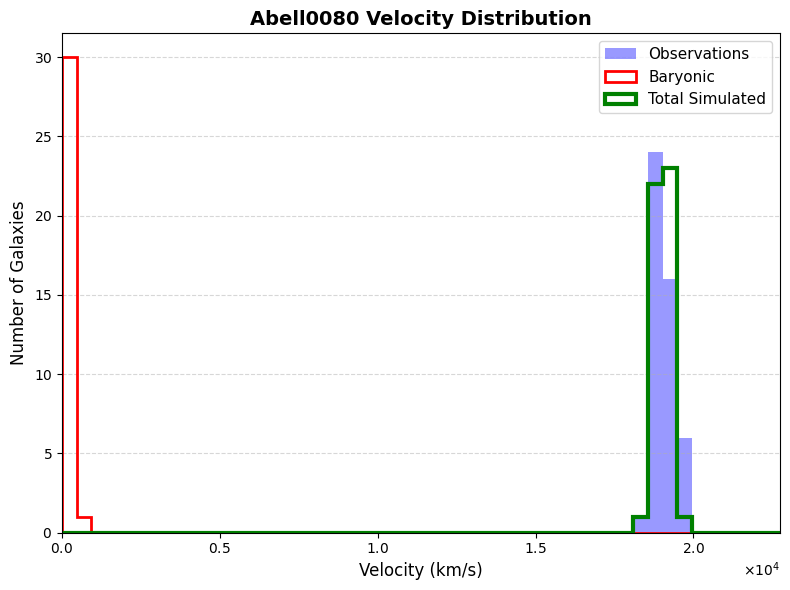

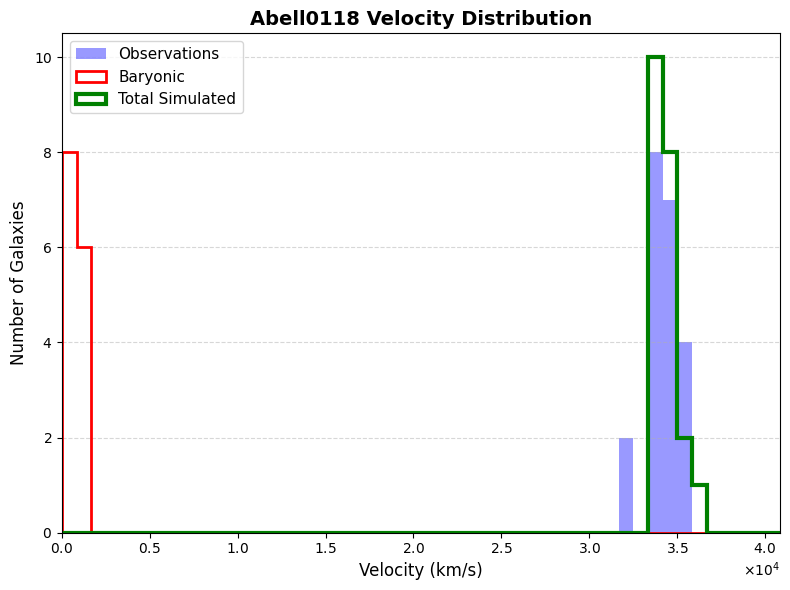

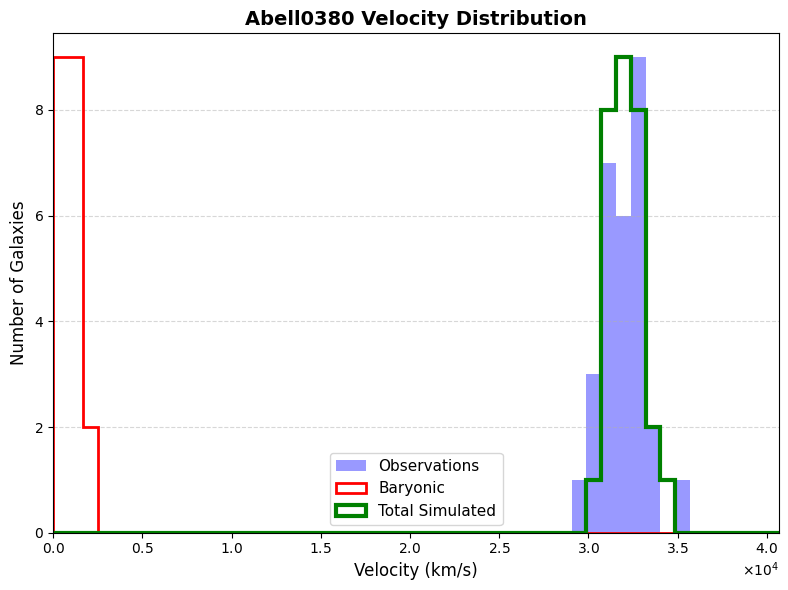

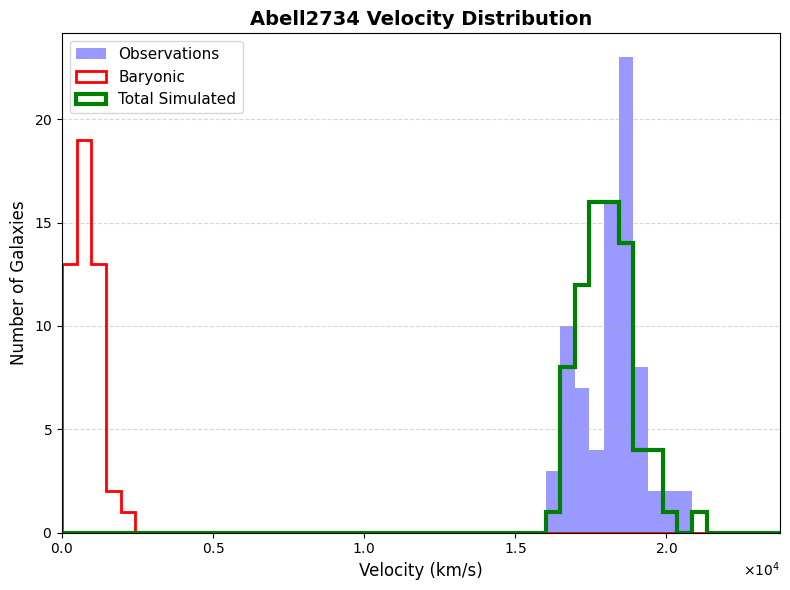

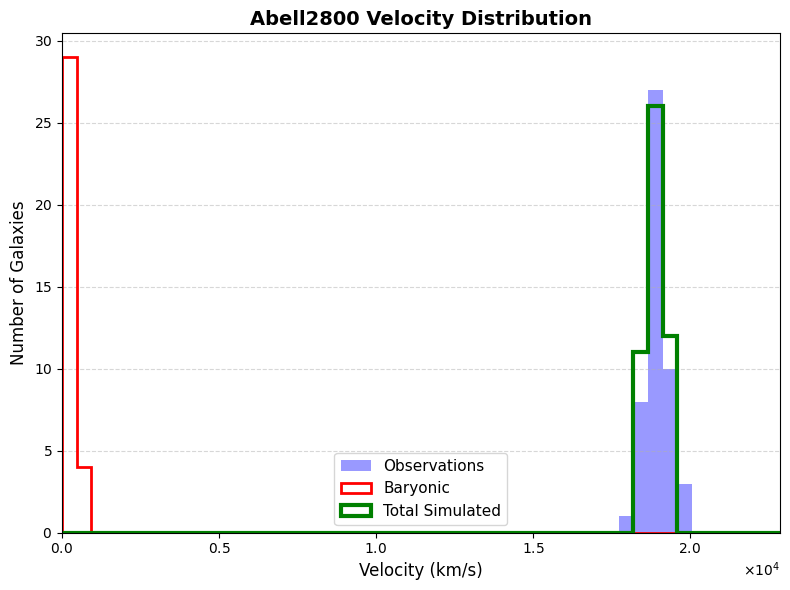

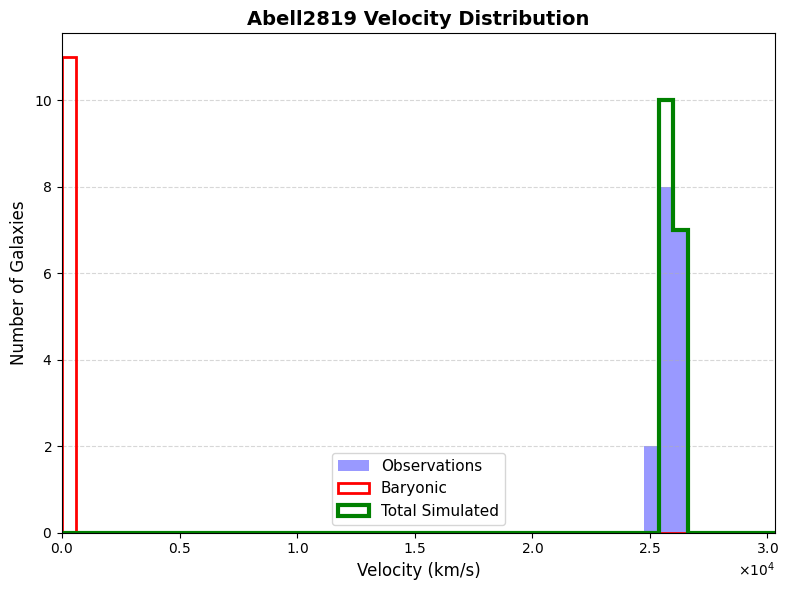

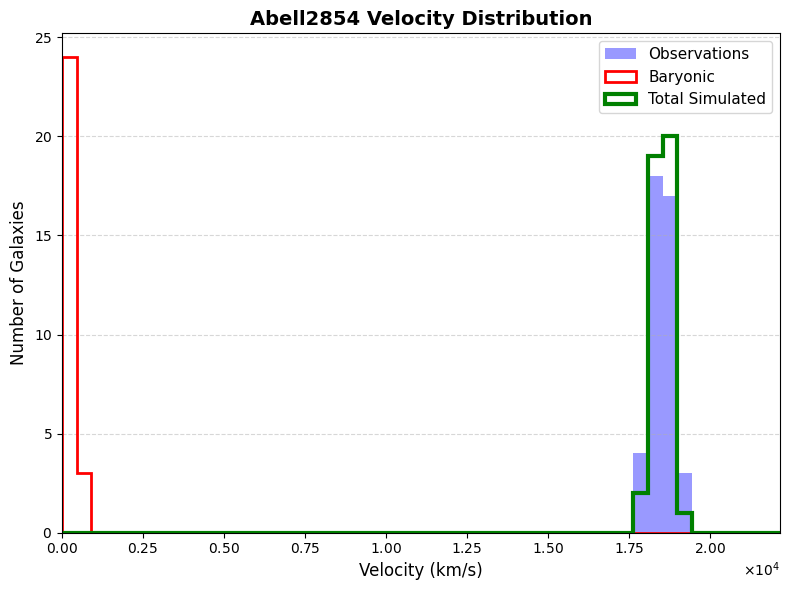

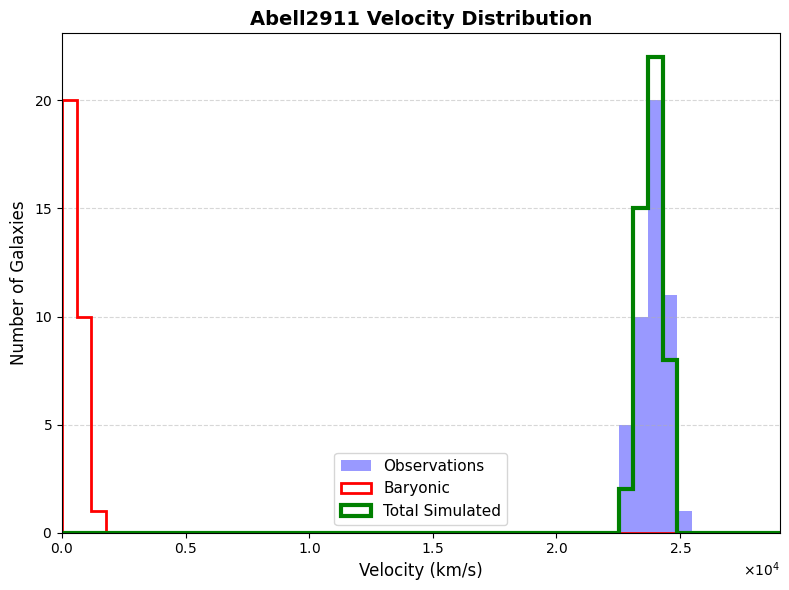

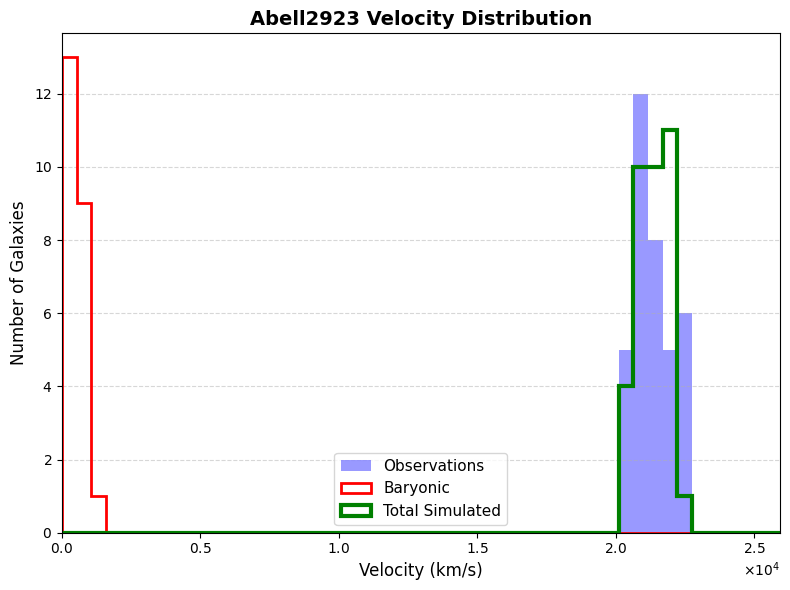

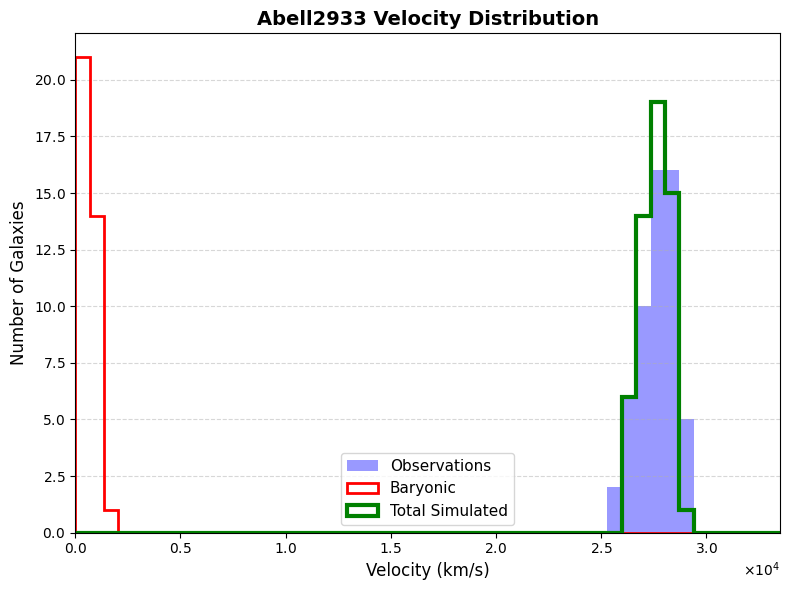

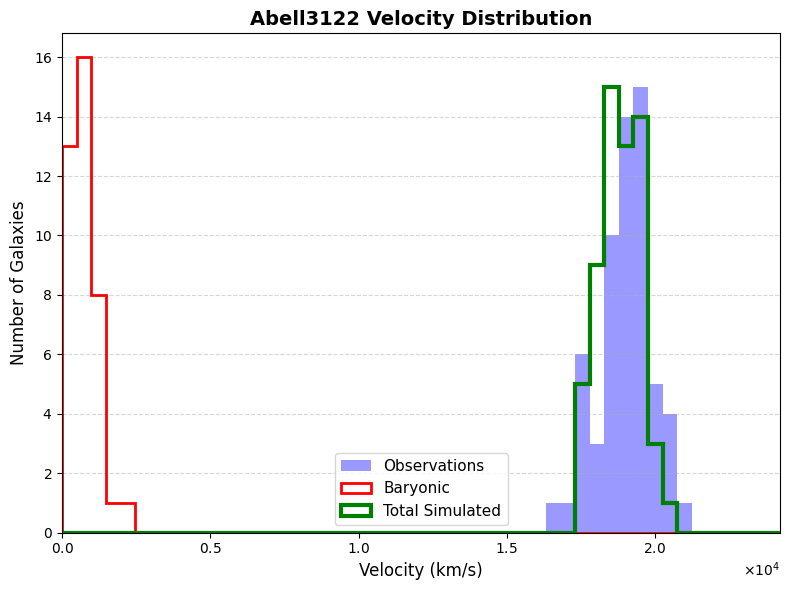

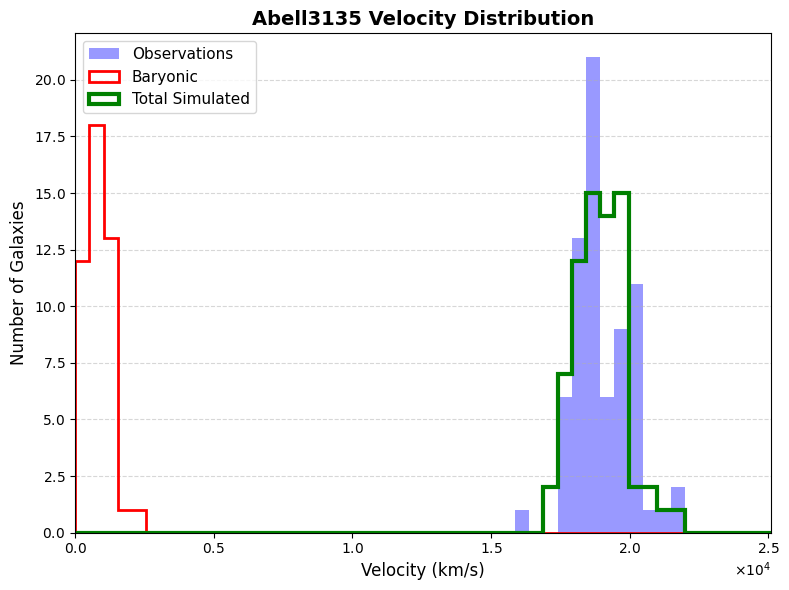

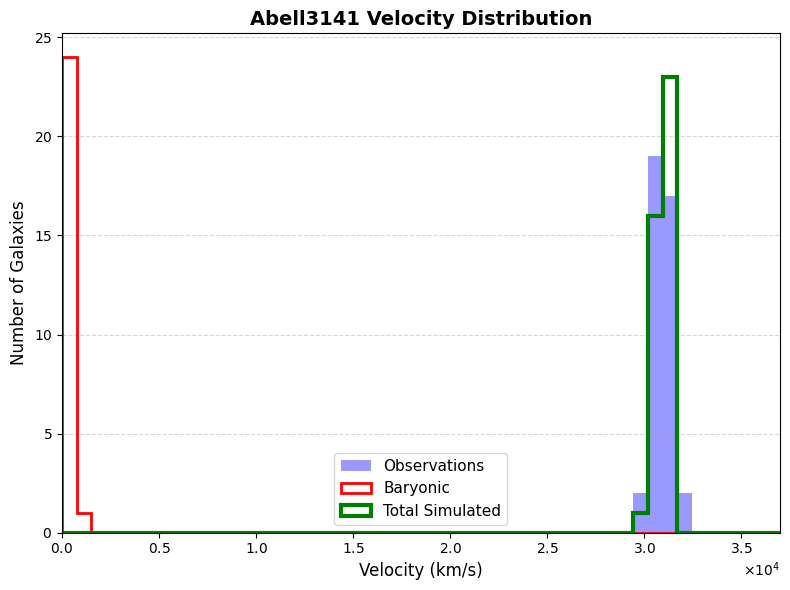

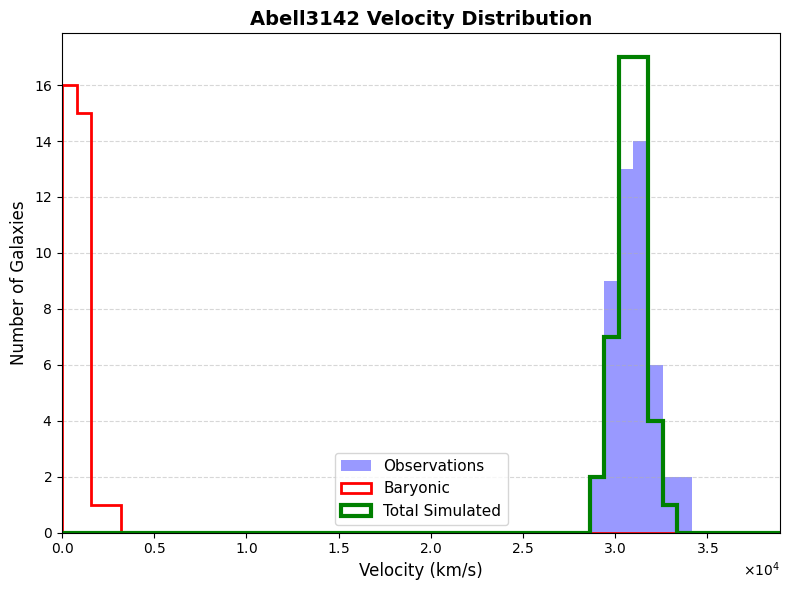

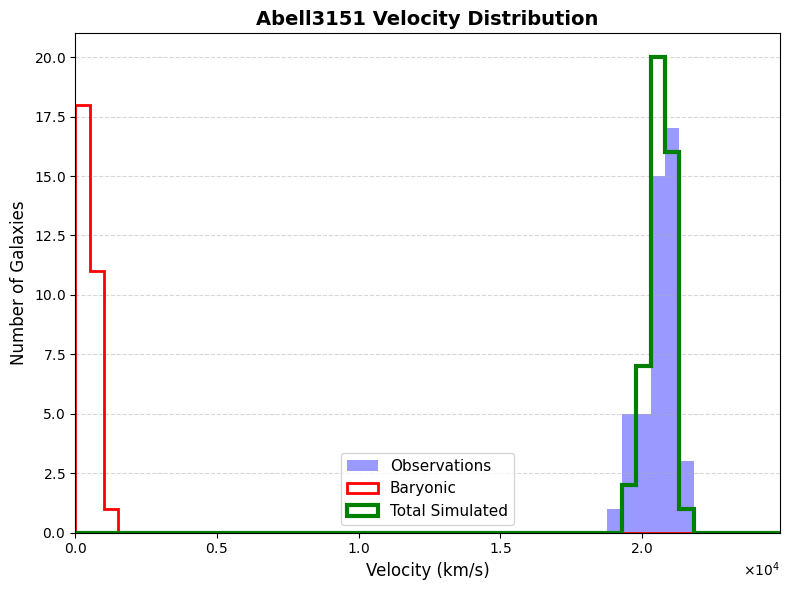

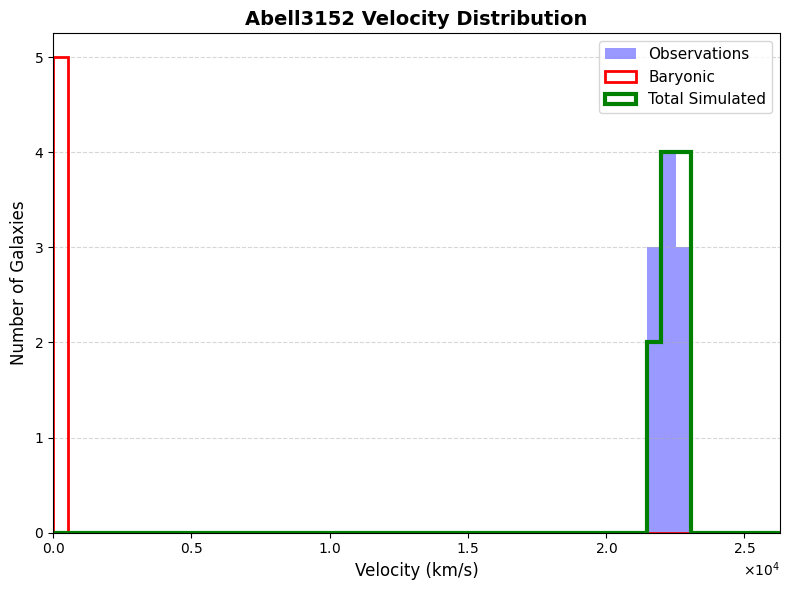

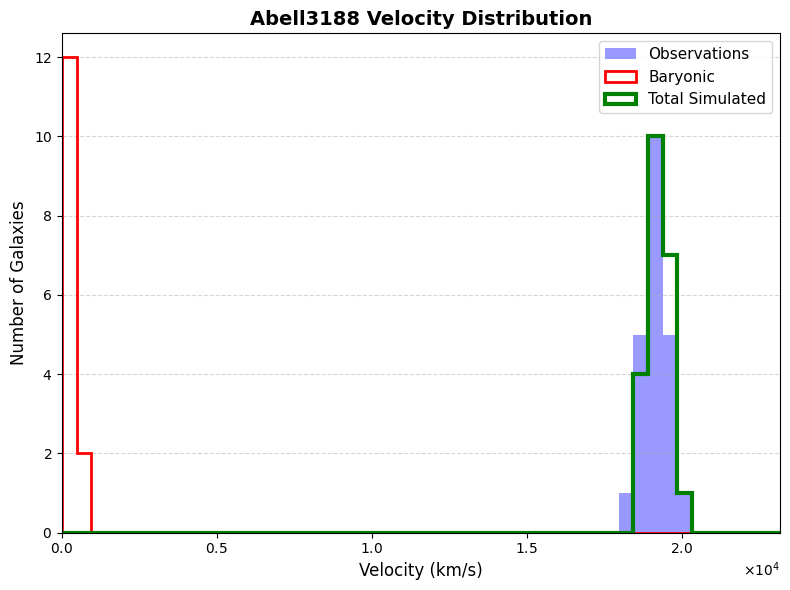

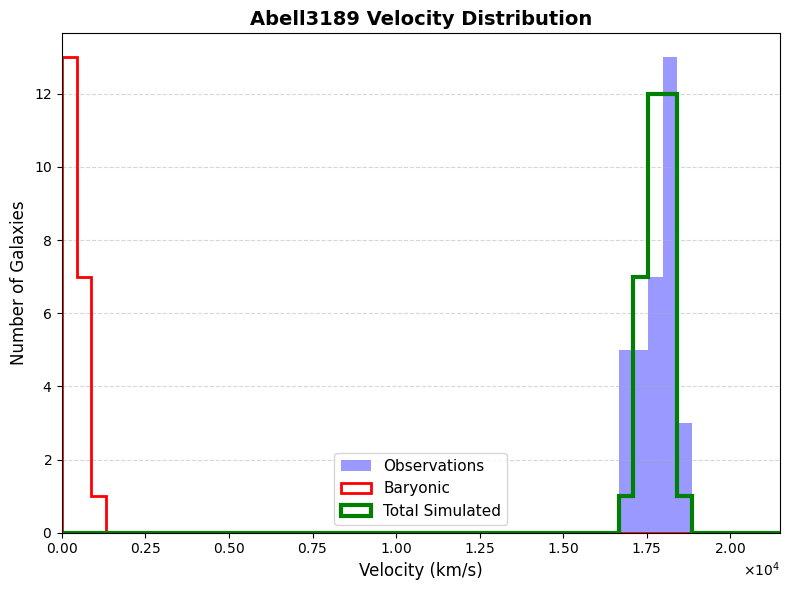

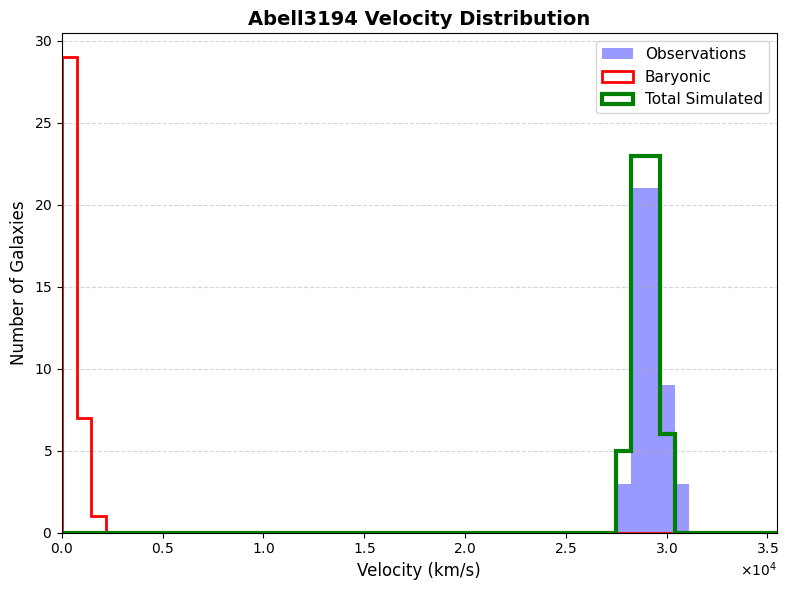

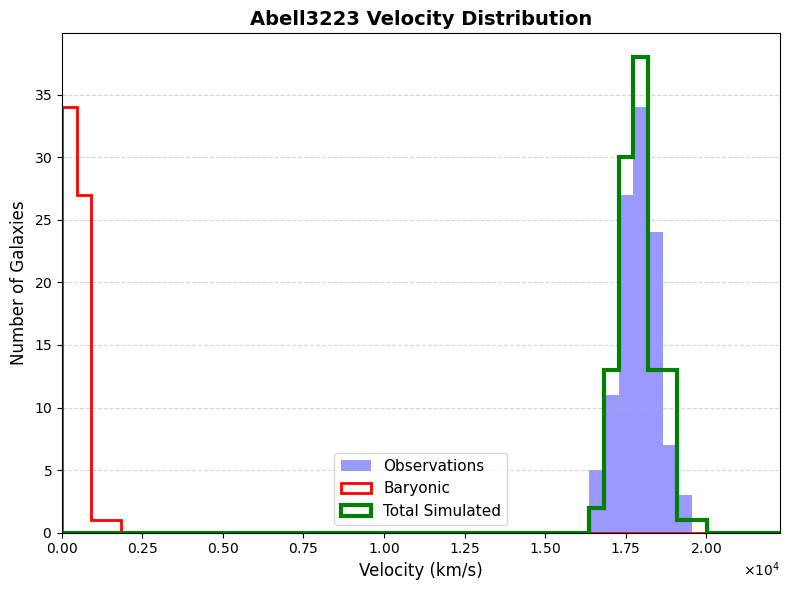

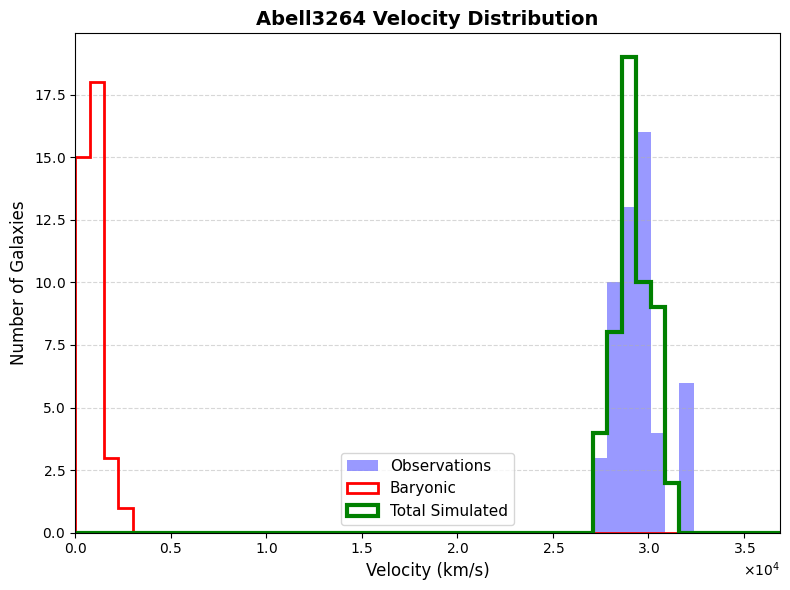

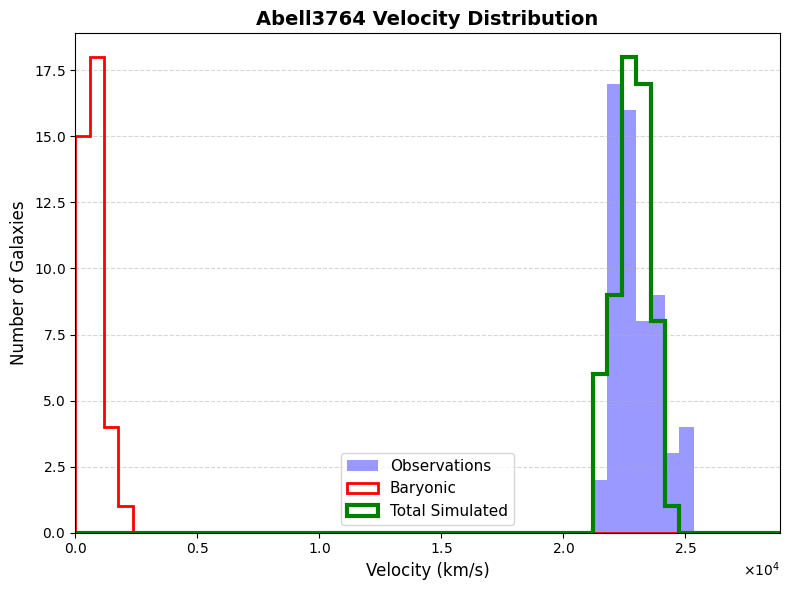

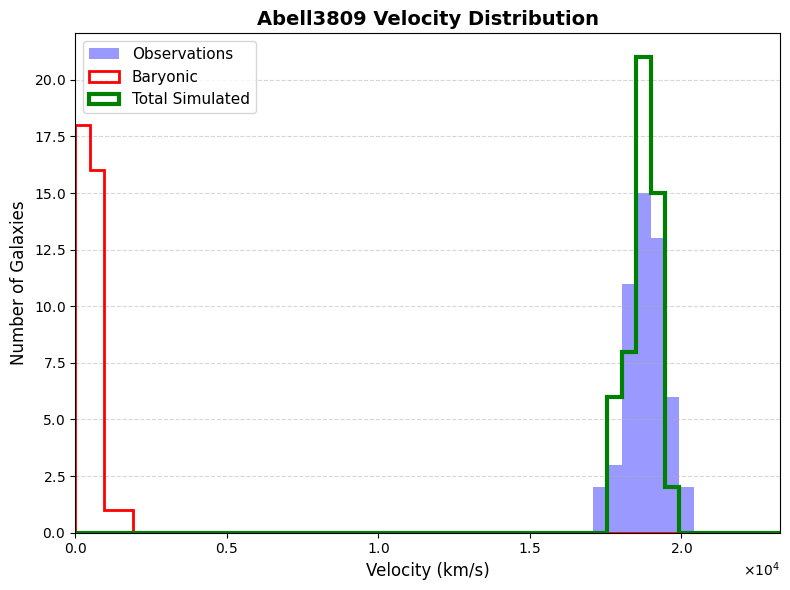

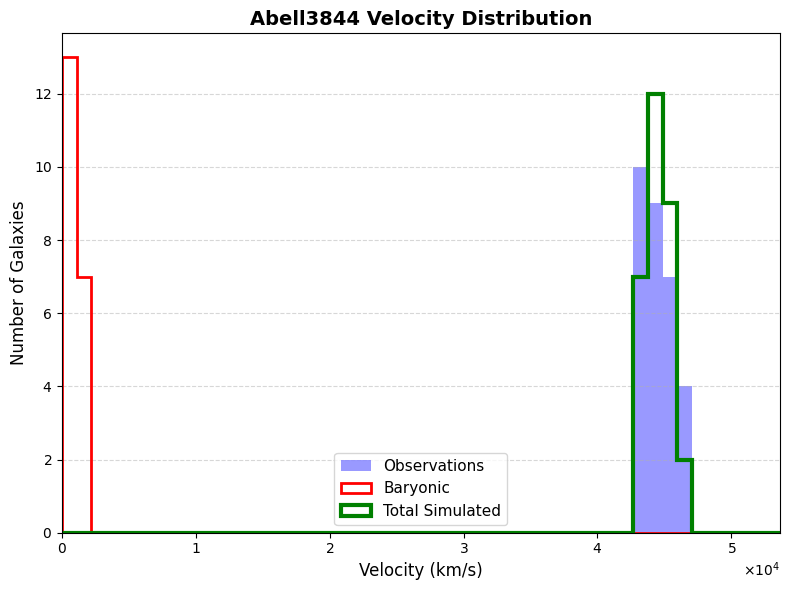

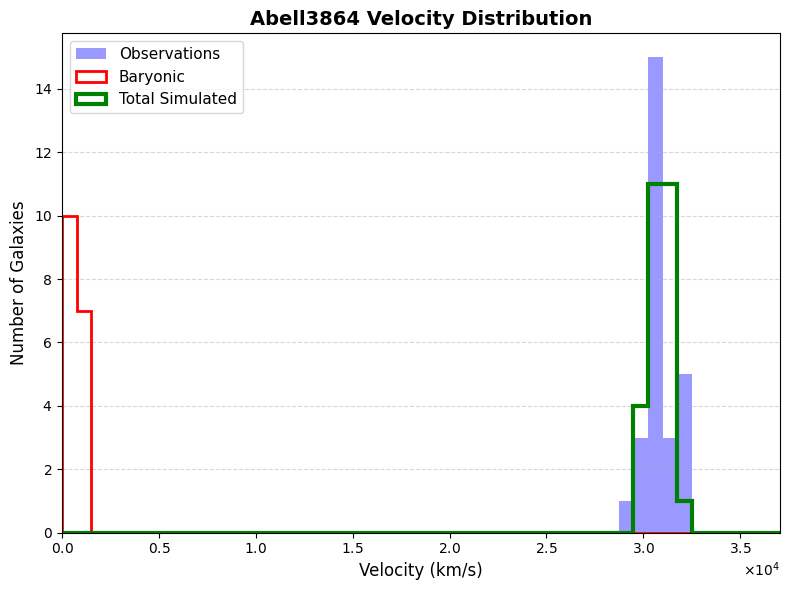

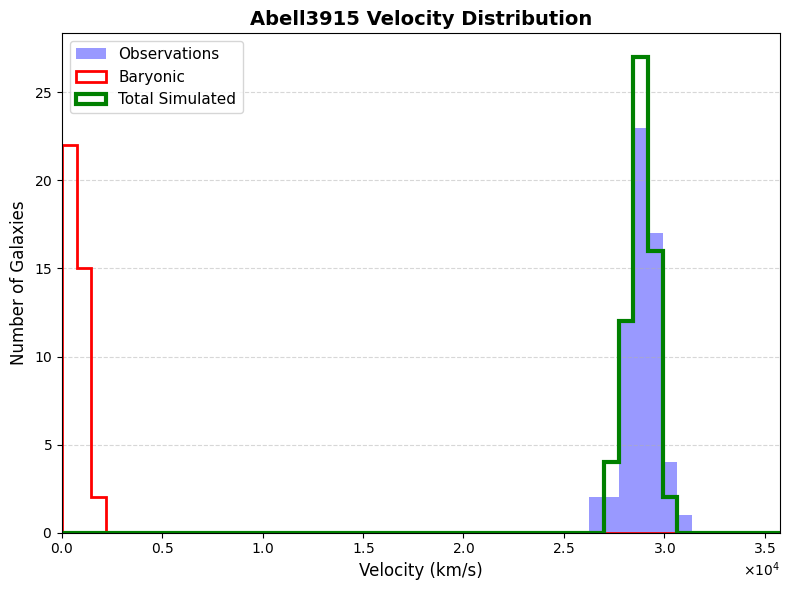

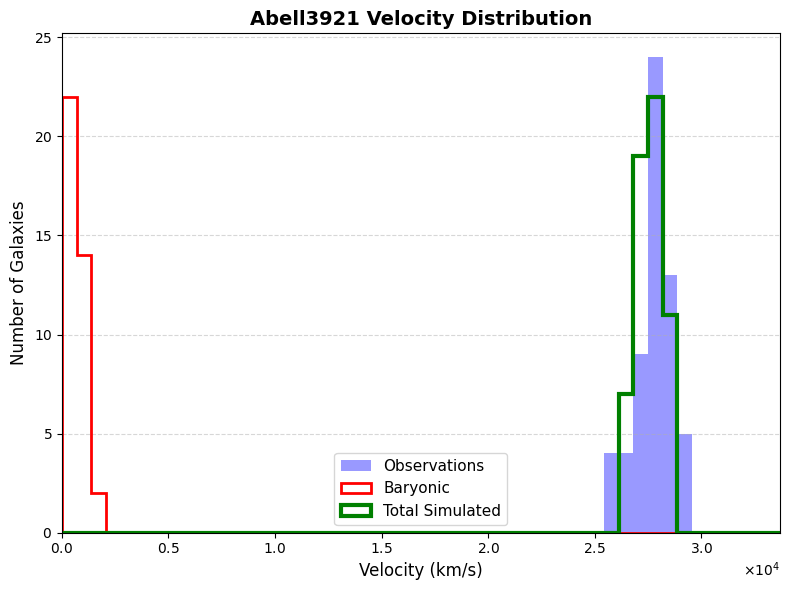

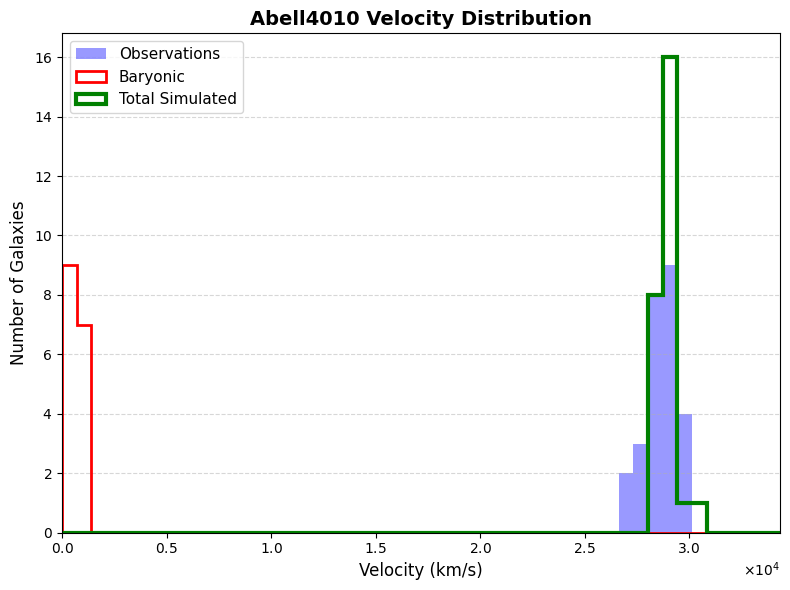

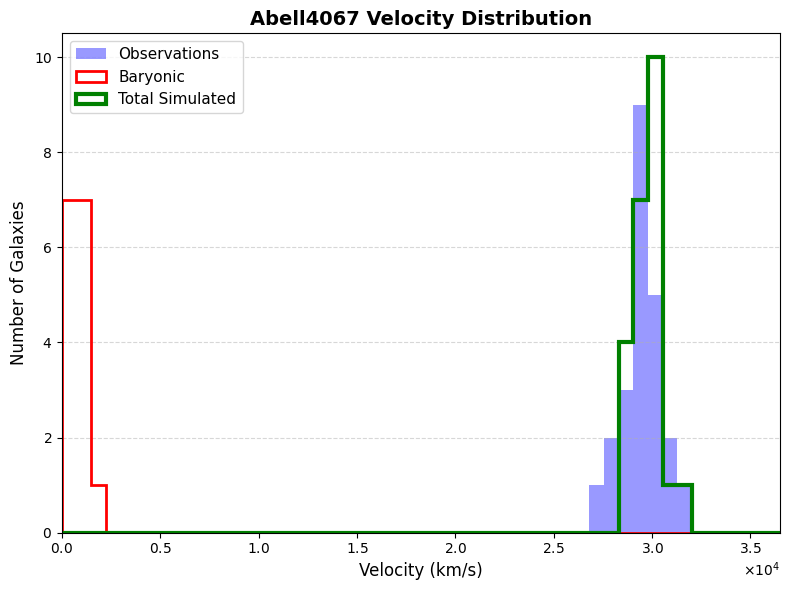

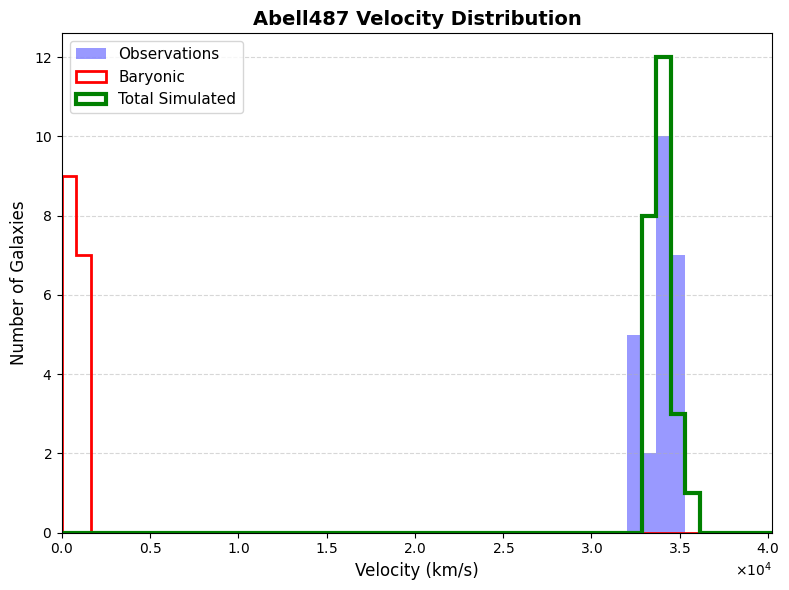

In [6]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt

for cluster_name, data in valid_clusters_for_plot.items():
    try:
        r_sorted = data["r_sorted"]
        observed_vel_sorted = data["observed_vel_sorted"]
        M_lum_r = data["M_lum_r"]
        sigma_global = data["sigma_global"]
        f_gas_global = data["f_gas_global"]

        # --- PLOT HISTOGRAM ---
        v_mean_obs = np.mean(observed_vel_sorted)
        sigma_mean_obs = np.std(observed_vel_sorted)
        rng = np.random.default_rng(seed=42)

        m_gas_r_local = (0.7 * (3.0 * sigma_global**2 * r_sorted) / G_grav) * f_gas_global
        M_baryonic_r = M_lum_r + m_gas_r_local
        sigma_bar_local = np.sqrt(np.maximum(1e-6, G_grav * M_baryonic_r / (3.0 * r_sorted)))

        v_bar = rng.normal(loc=sigma_bar_local, scale=sigma_mean_obs, size=len(r_sorted))
        v_sim_tot = rng.normal(loc=v_mean_obs, scale=sigma_global, size=len(r_sorted))

        x_max = observed_vel_sorted.max()
        padding = 0.15 * x_max
        bins = np.linspace(0, x_max + padding, 50)

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.hist(observed_vel_sorted, bins=bins, alpha=0.4, color='blue', label='Observations')
        ax.hist(v_bar, bins=bins, histtype='step', linewidth=2, color='red', label='Baryonic')
        ax.hist(v_sim_tot, bins=bins, histtype='step', linewidth=3, color='green', label='Total Simulated')

        ax.set_title(f"{cluster_name} Velocity Distribution", fontsize=14, fontweight='bold')
        ax.set_xlabel('Velocity (km/s)', fontsize=12)
        ax.set_ylabel('Number of Galaxies', fontsize=12)
        ax.set_xlim(0, x_max + padding)
        ax.legend(fontsize=11)
        ax.grid(True, axis='y', linestyle='--', alpha=0.5)

        ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error {cluster_name}: {str(e)}")

# 💡 FINAL QUESTION FOR STUDENTS:
# Look at the red curve (Baryons only). If the universe only had stars and gas,
# what would happen to the galaxies at the edges of the blue distribution?c^3")

## Step 5: Dark Matter Fraction vs Total Mass

Finally, let's visualize the relationship between the Total Mass of each clusters and its Dark Matter fraction.


In [9]:
import plotly.express as px
import pandas as pd

# --- INTERACTIVE SCATTER PLOT ---
if len(results_data) > 0:
    df_results = pd.DataFrame(results_data)

    fig_interactive = px.scatter(
        df_results,
        x="M_tot",
        y="Perc_DM",
        hover_name="Cluster",
        log_x=True,
        color_discrete_sequence=['forestgreen'],
        labels={
            "M_tot": "Total Mass (Solar Masses)",
            "Perc_DM": "Dark Matter Fraction (%)"
        },
        title="All Clusters: Dark Matter Fraction vs Total Mass"
    )

    fig_interactive.update_traces(
        marker=dict(size=12, line=dict(width=1, color='black'), opacity=0.8)
    )


    fig_interactive.update_layout(
        xaxis_range=[13, 16], # Range log 1e13 - 1e16
        yaxis_range=[88, 95],
        title_font_size=18,
        xaxis_title_font_size=14,
        yaxis_title_font_size=14
    )

    fig_interactive.show()

else:
    print("No valid clusters found to plot. Check your data filtering and uploads.")